## Topic: Advanced EDA + Project Enhancement (Sales Analysis Upgrade)
### Today’s Goal

👉 Upgrade pervious project into a professional analysis system

You will:
- Perform deeper analysis
- Extract meaningful business insights
- Improve visualization
- Think like a real analyst

### Step 0 — Import Libraries (VERY IMPORTANT)

👉 In Colab every notebook must start with imports.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 1 — Load Dataset

👉 We create the dataset again so the notebook runs from scratch.

In [2]:
# Create dataset
data = {
    "Product": ["Laptop", "Phone", "Tablet", "Laptop", "Phone", "Tablet"],
    "Region": ["North", "South", "East", "West", "North", "South"],
    "Sales": [50000, 30000, 20000, 60000, 35000, 25000],
    "Quantity": [5, 10, 8, 6, 12, 9]
}

df = pd.DataFrame(data)

# Display dataset
df

,Product,Region,Sales,Quantity
0,Laptop,North,50000,5
1,Phone,South,30000,10
2,Tablet,East,20000,8
3,Laptop,West,60000,6
4,Phone,North,35000,12
5,Tablet,South,25000,9


### Step 2 — Multi-Level Grouping (Product + Region)

👉 This shows which product performs best in each region

In [3]:
# Group by Product AND Region
product_region_sales = df.groupby(["Product", "Region"])["Sales"].sum()

product_region_sales

Product  Region
Laptop   North     50000
         West      60000
Phone    North     35000
         South     30000
Tablet   East      20000
         South     25000
Name: Sales, dtype: int64

What this means:
- We are analyzing two columns at once
- This is called multi-level grouping
- Used in real companies for regional performance

### Step 3 — Multiple Metrics Analysis (Professional Aggregation)

👉 Now we calculate multiple KPIs at once

In [4]:
# Aggregating multiple metrics
metrics = df.groupby("Product").agg({
    "Sales": ["sum", "mean"],   # total sales + average sales
    "Quantity": "sum"           # total quantity sold
})

metrics

Sales          Quantity
            sum     mean      sum
Product                          
Laptop   110000  55000.0       11
Phone     65000  32500.0       22
Tablet    45000  22500.0       17

Why this is powerful:
-Companies track KPIs (Key Performance Indicators)
- Here we created 3 KPIs:
  - Total Sales
  - Average Sales
  - Total Quantity

### Step 4 — Find Top Performing Product (Sorting)

In [5]:
# Total sales per product sorted descending
sorted_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

sorted_sales

,Sales
Product,
Laptop,110000
Phone,65000
Tablet,45000


Now results show ranking from best → worst.

### Step 5 — Find TOP Performers Automatically
#### Top Product

In [6]:
top_product = df.groupby("Product")["Sales"].sum().idxmax()
print("Top Product:", top_product)

Top Product: Laptop


#### Top Region

In [7]:
top_region = df.groupby("Region")["Sales"].sum().idxmax()
print("Top Region:", top_region)

Top Region: North


nterview tip:

idxmax() = returns name of highest value row.
### Step 6 — Horizontal Bar Chart (Professional Style)

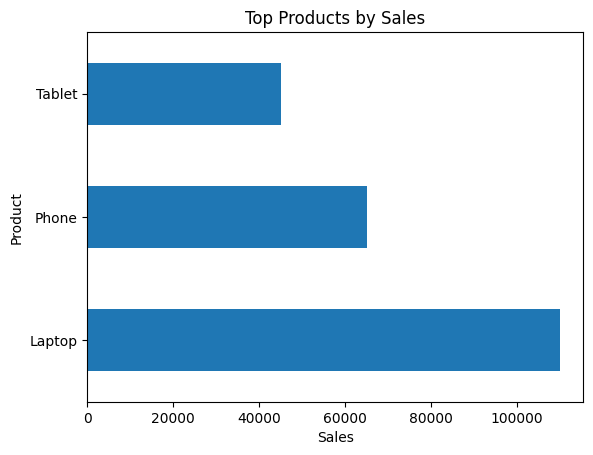

In [8]:
# Calculate product sales again
product_sales = df.groupby("Product")["Sales"].sum()

# Horizontal bar chart
product_sales.plot(kind="barh")

plt.title("Top Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

Horizontal charts are used in reports & dashboards.

### Step 7 — Compare Multiple Metrics in One Chart

👉 Compare Sales vs Quantity

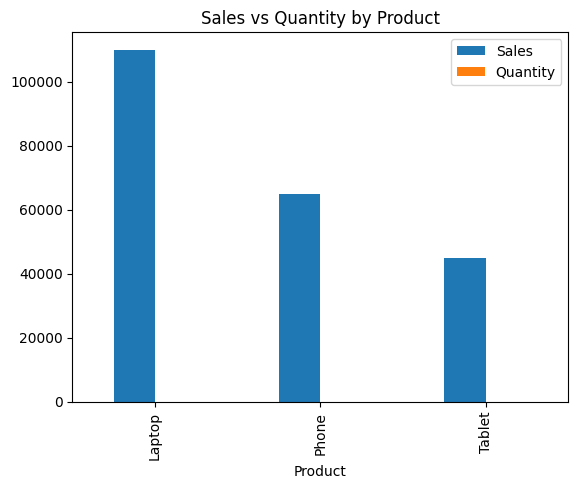

In [9]:
df.groupby("Product")[["Sales", "Quantity"]].sum().plot(kind="bar")

plt.title("Sales vs Quantity by Product")
plt.show()

This chart answers:

- Which product sells more money?
- Which product sells more units?

Very powerful comparison.

### 1: Normalize values  
Convert both to percentages or scale them:

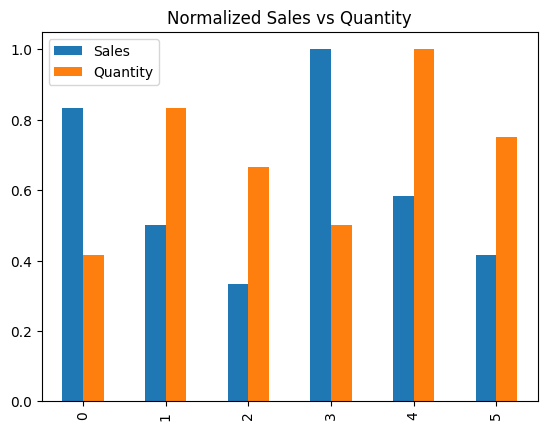

In [11]:
df[["Sales", "Quantity"]].apply(lambda x: x / x.max()).plot(kind="bar")
plt.title("Normalized Sales vs Quantity")
plt.show()

Both bars will be visible because they’re scaled to 0–1.
### 2: Use separate y‑axes  
Plot Sales and Quantity on different axes:

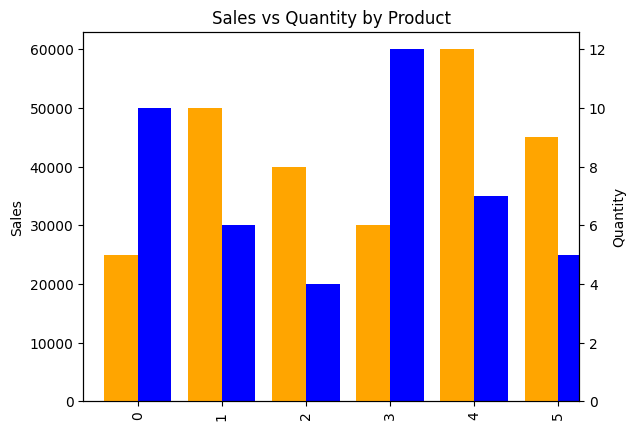

In [13]:
# Here’s how to plot Sales and Quantity with dual y‑axes:
import matplotlib.pyplot as plt

# Plot Sales on the left y-axis
ax = df["Sales"].plot(kind="bar", color="blue", width=0.4, position=0)
ax.set_ylabel("Sales")

# Create a second y-axis for Quantity
ax2 = ax.twinx()
df["Quantity"].plot(kind="bar", color="orange", width=0.4, position=1, ax=ax2)
ax2.set_ylabel("Quantity")

plt.title("Sales vs Quantity by Product")
plt.show()

What this does
- ax → plots Sales on the left y‑axis.

- ax.twinx() → creates a second axis (ax2) that shares the same x‑axis but has its own y‑axis.

- Now both Sales and Quantity bars are visible, each scaled to their own axis.

Sales on left axis, Quantity on right axis.

### 3: Plot two charts side‑by‑side

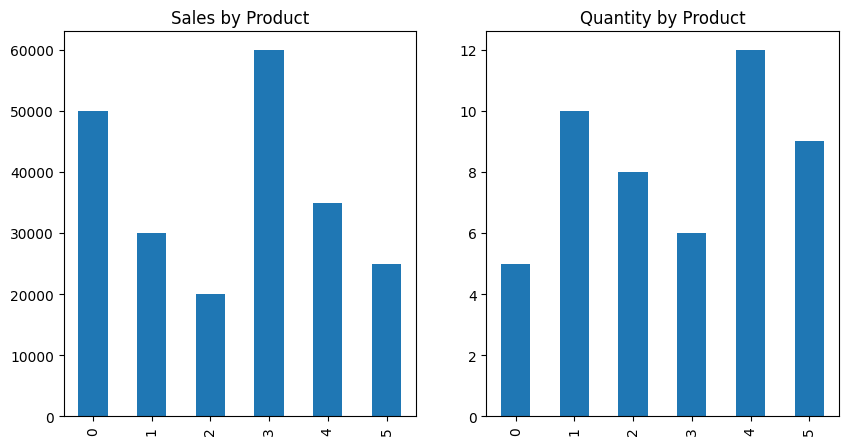

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
df["Sales"].plot(kind="bar", ax=axes[0], title="Sales by Product")
df["Quantity"].plot(kind="bar", ax=axes[1], title="Quantity by Product")
plt.show()

→ Clear comparison without scale conflict.
### Step 8 — BUSINESS INSIGHTS (MOST IMPORTANT)

This part turns you from coder → Data Analyst.

#### Which product sells the most?

From results:

- Laptop has highest sales

👉 Meaning:

- Customers prefer laptops
- High demand + high revenue

#### Business Decision:
- Increase laptop marketing
- Increase stock

### Which region performs best?

From analysis:

- North region is top

#### Business Decision:
- Expand branches in North
- Run ads in North
- Increase supply in North

#### Which product performs weakest?
- Tablet lowest sales

#### Business Decision:

- Improve marketing
- Reduce price
- Bundle with offers

### Add Analyst Feature (Revenue per Item)

👉 This shows product pricing performance.

In [10]:
# Revenue per item sold
df["Revenue_per_Item"] = df["Sales"] / df["Quantity"]

df

,Product,Region,Sales,Quantity,Revenue_per_Item
0,Laptop,North,50000,5,10000.000000
1,Phone,South,30000,10,3000.000000
2,Tablet,East,20000,8,2500.000000
3,Laptop,West,60000,6,10000.000000
4,Phone,North,35000,12,2916.666667
5,Tablet,South,25000,9,2777.777778


This metric helps company know:

Which product gives more profit per unit.

### A REAL ANALYSIS PROJECT

You used:
- GroupBy
- Multi-Aggregation
- Sorting
- KPI extraction
- Visualization
- Business Insights